<a href="https://www.kaggle.com/code/danuherath/sales-forecasting-time-series-analysis?scriptVersionId=220122847" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<h1 align="center"> Forecasting Sticker Sales - Time Series Analysis</h1>

<img
    src="https://www.kaggle.com/competitions/85723/images/header"
    alt=""
    width="300"
    height="200"
    style="display: block; margin: 0 auto; border-radius:15px"
/>

---

## Problem Definition

- Domain

    * Sales | Marketing | Finance

<br>

- Dataset
    * [Forecasting Sticker Sales](https://www.kaggle.com/competitions/playground-series-s5e1/data) dataset from Kaggle which contains 4 features (date, country, store and product). Train dataset contains 230,130 samples and each instance represents one sale.

<br>

- Objective
    * The goal of this project is to forecast sticker sales in different countries.

<br>

- Algorithms
    * Following regressiion algorithms are used to train models on the train dataset. The models are evaluated using the [Root Mean Squared Logarithmic Error (RMSLE)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_log_error.html) metric.


    1. [XGBoost (Extreme Gradient Boosting) Regressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor)
    2. [LightGBM Regressor](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html)
    3. [CatBoost Regressor](https://catboost.ai/docs/en/concepts/python-reference_catboostregressor)

<br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
%config InlineBackend.figure_format="svg"

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna

RSEED = 42


In [2]:
train_data = pd.read_csv("/kaggle/input/playground-series-s5e1/train.csv")
test_data = pd.read_csv("/kaggle/input/playground-series-s5e1/test.csv")


In [3]:
train_data.head()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [4]:
train_data.drop(columns=['id'], inplace=True)
test_data.drop(columns=['id'], inplace=True)
train_data.tail()


,date,country,store,product,num_sold
230125,2016-12-31,Singapore,Premium Sticker Mart,Holographic Goose,466.0
230126,2016-12-31,Singapore,Premium Sticker Mart,Kaggle,2907.0
230127,2016-12-31,Singapore,Premium Sticker Mart,Kaggle Tiers,2299.0
230128,2016-12-31,Singapore,Premium Sticker Mart,Kerneler,1242.0
230129,2016-12-31,Singapore,Premium Sticker Mart,Kerneler Dark Mode,1622.0


In [5]:
train_data.shape


(230130, 5)

---
# Step 1: Exploratory Data Analysis (EDA)
---

In [6]:
missing_values = train_data.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print(missing_values)


num_sold    8871
dtype: int64


In [7]:
duplicates = train_data[train_data.duplicated(keep=False)]
print(len(duplicates))
# print(duplicates)


0


In [8]:
train_data.nunique().sort_values(ascending=False)


num_sold    4037
date        2557
country        6
product        5
store          3
dtype: int64

In [9]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      230130 non-null  object 
 1   country   230130 non-null  object 
 2   store     230130 non-null  object 
 3   product   230130 non-null  object 
 4   num_sold  221259 non-null  float64
dtypes: float64(1), object(4)
memory usage: 8.8+ MB


In [10]:
test_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98550 entries, 0 to 98549
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     98550 non-null  object
 1   country  98550 non-null  object
 2   store    98550 non-null  object
 3   product  98550 non-null  object
dtypes: object(4)
memory usage: 3.0+ MB


In [11]:
target = 'num_sold'
train_data[target].describe()


count    221259.000000
mean        752.527382
std         690.165445
min           5.000000
25%         219.000000
50%         605.000000
75%        1114.000000
max        5939.000000
Name: num_sold, dtype: float64

In [12]:
train_data.groupby(['country']).count()


,date,store,product,num_sold
country,,,,
Canada,38355,38355,38355,34109
Finland,38355,38355,38355,38355
Italy,38355,38355,38355,38355
Kenya,38355,38355,38355,33730
Norway,38355,38355,38355,38355
Singapore,38355,38355,38355,38355


In [13]:
train_data.groupby('store').count()


,date,country,product,num_sold
store,,,,
Discount Stickers,76710,76710,76710,71531
Premium Sticker Mart,76710,76710,76710,75684
Stickers for Less,76710,76710,76710,74044


In [14]:
train_data.groupby('product').count()


,date,country,store,num_sold
product,,,,
Holographic Goose,46026,46026,46026,37220
Kaggle,46026,46026,46026,46026
Kaggle Tiers,46026,46026,46026,46026
Kerneler,46026,46026,46026,45962
Kerneler Dark Mode,46026,46026,46026,46025


In [15]:
train_data = train_data.dropna(subset=['num_sold'])
train_data.shape


(221259, 5)

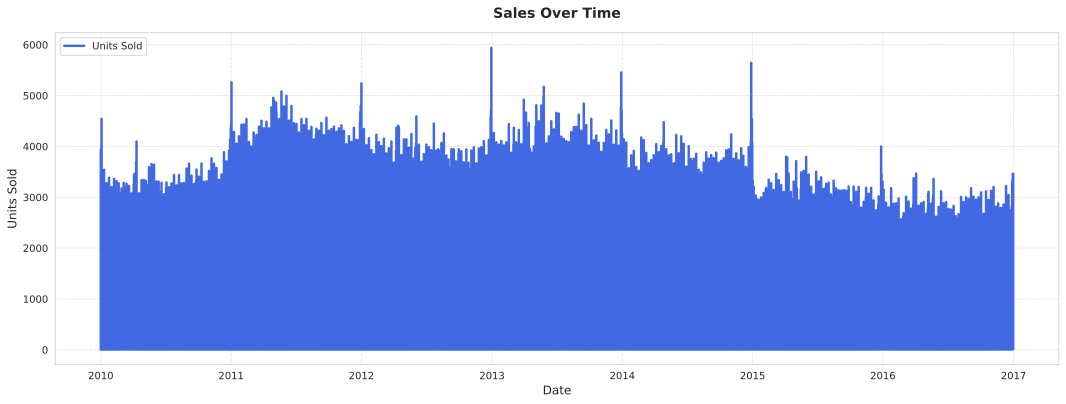

In [16]:
df = train_data.copy()

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))

plt.plot(df['num_sold'], color='royalblue', linewidth=2.5, label='Units Sold')

plt.title('Sales Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


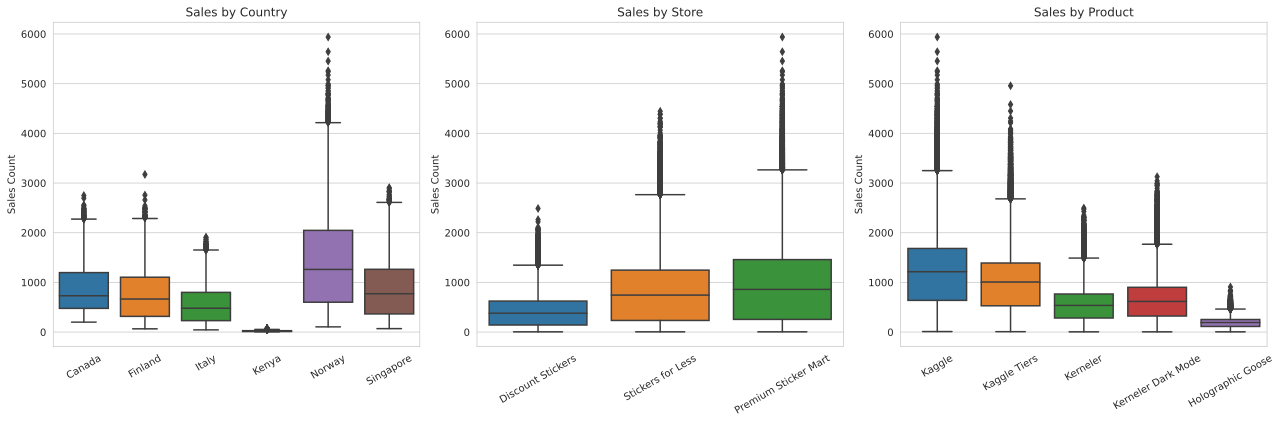

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='country', y='num_sold', data=train_data, ax=axes[0])
axes[0].set_title("Sales by Country")

sns.boxplot(x='store', y='num_sold', data=train_data, ax=axes[1])
axes[1].set_title("Sales by Store")

sns.boxplot(x='product', y='num_sold', data=train_data, ax=axes[2])
axes[2].set_title("Sales by Product")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Sales Count")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
# Step 2: Data Preprocessing
---

In [18]:
for col in ['country', 'store', 'product']:
    train_data[col] = train_data[col].astype('category')
    test_data[col] = test_data[col].astype('category')


In [19]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221259 entries, 1 to 230129
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   date      221259 non-null  object  
 1   country   221259 non-null  category
 2   store     221259 non-null  category
 3   product   221259 non-null  category
 4   num_sold  221259 non-null  float64 
dtypes: category(3), float64(1), object(1)
memory usage: 5.7+ MB


In [20]:
train_data.head()


,date,country,store,product,num_sold
1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
5,2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0


In [21]:
for df in [train_data, test_data]:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    df.drop(columns=['date'], inplace=True)

train_data.head()


,country,store,product,num_sold,year,month,day,day_of_week,is_weekend
1,Canada,Discount Stickers,Kaggle,973.0,2010,1,1,4,0
2,Canada,Discount Stickers,Kaggle Tiers,906.0,2010,1,1,4,0
3,Canada,Discount Stickers,Kerneler,423.0,2010,1,1,4,0
4,Canada,Discount Stickers,Kerneler Dark Mode,491.0,2010,1,1,4,0
5,Canada,Stickers for Less,Holographic Goose,300.0,2010,1,1,4,0


In [ ]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221259 entries, 1 to 230129
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   country      221259 non-null  category
 1   store        221259 non-null  category
 2   product      221259 non-null  category
 3   num_sold     221259 non-null  float64 
 4   year         221259 non-null  int32   
 5   month        221259 non-null  int32   
 6   day          221259 non-null  int32   
 7   day_of_week  221259 non-null  int32   
 8   is_weekend   221259 non-null  int64   
dtypes: category(3), float64(1), int32(4), int64(1)
memory usage: 9.1 MB


In [ ]:
X = train_data.drop('num_sold', axis=1)
y = train_data['num_sold']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RSEED)


In [ ]:
cat_features = ['country', 'store', 'product']
num_features = [col for col in X.columns if col not in cat_features]


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),

        ('categorical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),
        ]), cat_features)
    ],
    remainder='passthrough'
)

preprocessor


---
# Step 3: Model Training & Evaluation
---

In [ ]:
def root_mean_squared_log_error(y_true, y_pred):
    
    log_true = np.log1p(y_true)
    
    y_pred = np.maximum(y_pred, 0)  # Ensure no negative values
    log_pred = np.log1p(y_pred)
    
    squared_diff = (log_true - log_pred) ** 2
    
    return np.sqrt(np.mean(squared_diff))


In [27]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    
    model = XGBRegressor(random_state=RSEED, **params)
    pipeline = make_pipeline(preprocessor, model)
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    
    return root_mean_squared_log_error(y_val, y_pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)


best_params = study.best_params
best_xgb = XGBRegressor(random_state=RSEED, **best_params)


[I 2025-01-31 19:19:58,809] A new study created in memory with name: no-name-9ecc2fb3-0415-468c-a7cf-265998a084f1


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-01-31 19:20:07,635] Trial 0 finished with value: 0.23012005860299203 and parameters: {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.07411515472253634, 'subsample': 0.9080419930129269, 'colsample_bytree': 0.9584597127062006}. Best is trial 0 with value: 0.23012005860299203.
[I 2025-01-31 19:20:09,082] Trial 1 finished with value: 0.9445866405949371 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05657291011515181, 'subsample': 0.7890352653391745, 'colsample_bytree': 0.5601631444327821}. Best is trial 0 with value: 0.23012005860299203.
[I 2025-01-31 19:20:25,185] Trial 2 finished with value: 0.38390312378366986 and parameters: {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.027617917804195105, 'subsample': 0.9987885824149505, 'colsample_bytree': 0.5634467871770412}. Best is trial 0 with value: 0.23012005860299203.
[I 2025-01-31 19:20:30,303] Trial 3 finished with value: 0.36377698628694327 and parameters: {'n_estimators': 500, 'max_de

In [28]:
# best_params = {
#     'n_estimators': 900, 
#     'max_depth': 10, 
#     'learning_rate': 0.012897137410614976, 
#     'subsample': 0.5655745182285007, 
#     'colsample_bytree': 0.878060556856801
# }

# best_xgb = XGBRegressor(random_state=RSEED, **best_params)

In [29]:
pipeline = make_pipeline(preprocessor, best_xgb)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)

xgb_rmse = root_mean_squared_log_error(y_val, y_pred)
print(f"RMSE of XGB: {xgb_rmse}")


RMSE of XGB: 0.07474982801458324


In [30]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221259 entries, 1 to 230129
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   country      221259 non-null  category
 1   store        221259 non-null  category
 2   product      221259 non-null  category
 3   num_sold     221259 non-null  float64 
 4   year         221259 non-null  int32   
 5   month        221259 non-null  int32   
 6   day          221259 non-null  int32   
 7   day_of_week  221259 non-null  int32   
 8   is_weekend   221259 non-null  int64   
dtypes: category(3), float64(1), int32(4), int64(1)
memory usage: 9.1 MB


---
# Step 4: Test Data Prediction
---

In [31]:
test_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98550 entries, 0 to 98549
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   country      98550 non-null  category
 1   store        98550 non-null  category
 2   product      98550 non-null  category
 3   year         98550 non-null  int32   
 4   month        98550 non-null  int32   
 5   day          98550 non-null  int32   
 6   day_of_week  98550 non-null  int32   
 7   is_weekend   98550 non-null  int64   
dtypes: category(3), int32(4), int64(1)
memory usage: 2.5 MB


In [32]:
test_data_predictions = pipeline.predict(test_data)
test_data_predictions


array([ 185.45872,  847.7476 ,  757.31647, ..., 1951.5479 , 1054.2438 ,
       1242.9147 ], dtype=float32)

In [33]:
submission = pd.read_csv('/kaggle/input/playground-series-s5e1/sample_submission.csv')
submission[target] = test_data_predictions

submission.to_csv('submission.csv', index=False)
submission.head()


,id,num_sold
0,230130,185.458725
1,230131,847.747620
2,230132,757.316467
3,230133,383.673096
4,230134,461.119751
